In [4]:

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.manifold import TSNE

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt

from sklearn.ensemble import AdaBoostClassifier
from sklearn import datasets
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline


from sklearn.metrics import roc_auc_score
from sklearn.metrics import log_loss
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import logging

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve

import matplotlib.pyplot as plt


In [5]:
#set_seed
def set_seed(seed=15806679):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [6]:
data = pd.read_csv('musicData.csv')
unique_keys = data['music_genre'].unique()
print(unique_keys)
X = data.values
print(data.dtypes)
print("Shape of the data:", X.shape)
key_mapping = {
    'C': 0, 'C#': 1, 'D': 2, 'D#': 3, 'E': 4, 'F': 5, 'F#': 6, 'G': 7, 'G#': 8, 'A': 9, 'A#': 10, 'B': 11
}
data['key'] = data['key'].map(key_mapping)

['Electronic' 'Anime' nan 'Jazz' 'Alternative' 'Country' 'Rap' 'Blues'
 'Rock' 'Classical' 'Hip-Hop']
instance_id         float64
artist_name          object
track_name           object
popularity          float64
acousticness        float64
danceability        float64
duration_ms         float64
energy              float64
instrumentalness    float64
key                  object
liveness            float64
loudness            float64
mode                 object
speechiness         float64
tempo                object
obtained_date        object
valence             float64
music_genre          object
dtype: object
Shape of the data: (50005, 18)


In [7]:
#Display unique values in each categorical column to decide on encoding strategy
for column in data.columns:
    if data[column].dtype == 'object':  # Typically, object dtype implies string entries which are often categorical
        print(f"{column}: {data[column].nunique()} unique labels")
        #print(data[column].unique()[:10])  # Show up to the first 10 uniqu

artist_name: 6863 unique labels
track_name: 41699 unique labels
mode: 2 unique labels
tempo: 29394 unique labels
obtained_date: 5 unique labels
music_genre: 10 unique labels


In [8]:
 #Display unique values in each categorical column to decide on encoding strategy
for column in data.columns:
    if data[column].dtype == 'object':  # Typically, object dtype implies string entries which are often categorical
        print(f"{column}: {data[column].nunique()} unique labels")
        #print(data[column].unique()[:10])  # Show up to the first 10 uniqu

artist_name: 6863 unique labels
track_name: 41699 unique labels
mode: 2 unique labels
tempo: 29394 unique labels
obtained_date: 5 unique labels
music_genre: 10 unique labels


In [9]:
# analyzed the info of all the "object" type variable
# Calculate the number of unique artist names
unique_artists_count = data['artist_name'].nunique()
# Print the count of unique artist names
print("Number of unique artists:", unique_artists_count)

unique_track_count = data['track_name'].nunique()
print("number of unqiue_track_cout",unique_track_count)

unique_mode=data['mode'].nunique()
print("number of uinque_mode",unique_mode)



unique_tempo=data['tempo'].nunique()
print("number of unique_temp",unique_tempo)



unique_tempo=data['obtained_date'].unique()
print("obtained date",unique_tempo)



Number of unique artists: 6863
number of unqiue_track_cout 41699
number of uinque_mode 2
number of unique_temp 29394
obtained date ['4-Apr' '3-Apr' '5-Apr' '1-Apr' nan '0/4']


In [10]:
# handle music genre encode genre 10 catories to number 
label_encoder = LabelEncoder()
data['music_genre'] = label_encoder.fit_transform(data['music_genre'])

# handle mode 

if 'mode' in data.columns:
    data = pd.get_dummies(data, columns=['mode'], drop_first=True)
else:
    print("Column 'mode' not found in DataFrame.")

# handle obtained date 


if 'obtained_date' in data.columns:
    # Correct handling of inplace operations
    data['obtained_date'].replace({'0/4': '1-Apr'}, inplace=True)
    data['obtained_date'].fillna('Unknown', inplace=True)
    data = pd.get_dummies(data, columns=['obtained_date'])
else:
    print("Column 'obtained_date' not found in DataFrame.")


# handle tempo
data['tempo'] = pd.to_numeric(data['tempo'], errors='coerce')  # Convert to numeric, 
data['tempo'] = (data['tempo'] - data['tempo'].mean()) / data['tempo'].std()  # Standardize



from sklearn.feature_extraction import FeatureHasher
import pandas as pd

# Assuming 'data' is your DataFrame and it's loaded correctly
# Splitting each name into a list of words (simplest approach: treat each name as a single-item list)
 #Convert each name into a list of words where each word is explicitly cast to string
data['artist_name'] = data['artist_name'].apply(lambda x: [str(x)])
data['track_name'] = data['track_name'].apply(lambda x: [str(x)])

# Initialize the FeatureHasher with 10 features per the string input type
hasher = FeatureHasher(n_features=10, input_type='string')

# Transform 'artist_name'
hashed_features = hasher.transform(data['artist_name'])
hashed_df = pd.DataFrame(hashed_features.toarray(), columns=['artist_feature_' + str(i) for i in range(10)])
data = pd.concat([data.drop(['artist_name'], axis=1), hashed_df], axis=1)

# Transform 'track_name'
hashed_features = hasher.transform(data['track_name'])
hashed_df = pd.DataFrame(hashed_features.toarray(), columns=['track_feature_' + str(i) for i in range(10)])
data = pd.concat([data.drop(['track_name'], axis=1), hashed_df], axis=1)

# Print the first few rows of the DataFrame to check the new columns
print(data.head())

   instance_id  popularity  acousticness  danceability  duration_ms  energy  \
0      32894.0        27.0       0.00468         0.652         -1.0   0.941   
1      46652.0        31.0       0.01270         0.622     218293.0   0.890   
2      30097.0        28.0       0.00306         0.620     215613.0   0.755   
3      62177.0        34.0       0.02540         0.774     166875.0   0.700   
4      24907.0        32.0       0.00465         0.638     222369.0   0.587   

   instrumentalness   key  liveness  loudness  ...  track_feature_0  \
0           0.79200  10.0     0.115    -5.201  ...              0.0   
1           0.95000   2.0     0.124    -7.043  ...              0.0   
2           0.01180   8.0     0.534    -4.617  ...              0.0   
3           0.00253   1.0     0.157    -4.498  ...              0.0   
4           0.90900   6.0     0.157    -6.266  ...              0.0   

   track_feature_1  track_feature_2  track_feature_3  track_feature_4  \
0              0.0       

/var/folders/k7/j3jcyhwx4cscdxvtf500xwc00000gn/T/ipykernel_17709/2296893177.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['obtained_date'].replace({'0/4': '1-Apr'}, inplace=True)


In [11]:

from sklearn.preprocessing import StandardScaler

# Standardizing numerical fields
scaler = StandardScaler()
numerical_cols = ['popularity', 'acousticness', 'danceability', 'duration_ms', 'energy',
                  'instrumentalness', 'key', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence']

data[numerical_cols] = scaler.fit_transform(data[numerical_cols])
print(data[numerical_cols].isna().sum())

popularity             5
acousticness           5
danceability           5
duration_ms            5
energy                 5
instrumentalness       5
key                    5
liveness               5
loudness               5
speechiness            5
tempo               4985
valence                5
dtype: int64


In [12]:
# Checking means and standard deviations of the standardized fields
means = data[numerical_cols].mean(axis=0)  # Should be close to 0
stds = data[numerical_cols].std(axis=0)    # Should be close to 1

print("Means after standardization:\n", means)
print("Standard deviations after standardization:\n", stds)

Means after standardization:
 popularity          1.568878e-16
acousticness       -3.296918e-17
danceability        5.320544e-16
duration_ms        -1.074341e-16
energy             -1.818989e-17
instrumentalness   -2.273737e-17
key                 5.222489e-17
liveness           -1.011813e-16
loudness            4.240519e-16
speechiness         2.091838e-16
tempo               1.073232e-17
valence            -1.250555e-16
dtype: float64
Standard deviations after standardization:
 popularity          1.000010
acousticness        1.000010
danceability        1.000010
duration_ms         1.000010
energy              1.000010
instrumentalness    1.000010
key                 1.000010
liveness            1.000010
loudness            1.000010
speechiness         1.000010
tempo               1.000011
valence             1.000010
dtype: float64


In [66]:

print(data.dtypes)  # This will list all column names along with their data types


instance_id              float64
popularity               float64
acousticness             float64
danceability             float64
duration_ms              float64
energy                   float64
instrumentalness         float64
key                      float64
liveness                 float64
loudness                 float64
speechiness              float64
tempo                    float64
valence                  float64
music_genre                int64
mode_Minor                  bool
obtained_date_1-Apr         bool
obtained_date_3-Apr         bool
obtained_date_4-Apr         bool
obtained_date_5-Apr         bool
obtained_date_Unknown       bool
artist_feature_0         float64
artist_feature_1         float64
artist_feature_2         float64
artist_feature_3         float64
artist_feature_4         float64
artist_feature_5         float64
artist_feature_6         float64
artist_feature_7         float64
artist_feature_8         float64
artist_feature_9         float64
track_feat

In [13]:

# Total number of missing values per column
missing_values_count = data.isnull().sum()
print("\nNumber of missing values per column:")
print(missing_values_count)

# Calculate the percentage of missing values
total_cells = np.product(data.shape)
total_missing = missing_values_count.sum()
percentage_missing = (total_missing / total_cells) * 100

print("\nPercentage of data missing in the dataset:", percentage_missing)

# Percentage of missing values per column
percentage_missing_per_column = (missing_values_count / len(data)) * 100
print("\nPercentage of missing values per column:")
print(percentage_missing_per_column)


Number of missing values per column:
instance_id                 5
popularity                  5
acousticness                5
danceability                5
duration_ms                 5
energy                      5
instrumentalness            5
key                         5
liveness                    5
loudness                    5
speechiness                 5
tempo                    4985
valence                     5
music_genre                 0
mode_Minor                  0
obtained_date_1-Apr         0
obtained_date_3-Apr         0
obtained_date_4-Apr         0
obtained_date_5-Apr         0
obtained_date_Unknown       0
artist_feature_0            0
artist_feature_1            0
artist_feature_2            0
artist_feature_3            0
artist_feature_4            0
artist_feature_5            0
artist_feature_6            0
artist_feature_7            0
artist_feature_8            0
artist_feature_9            0
track_feature_0             0
track_feature_1             0
tr

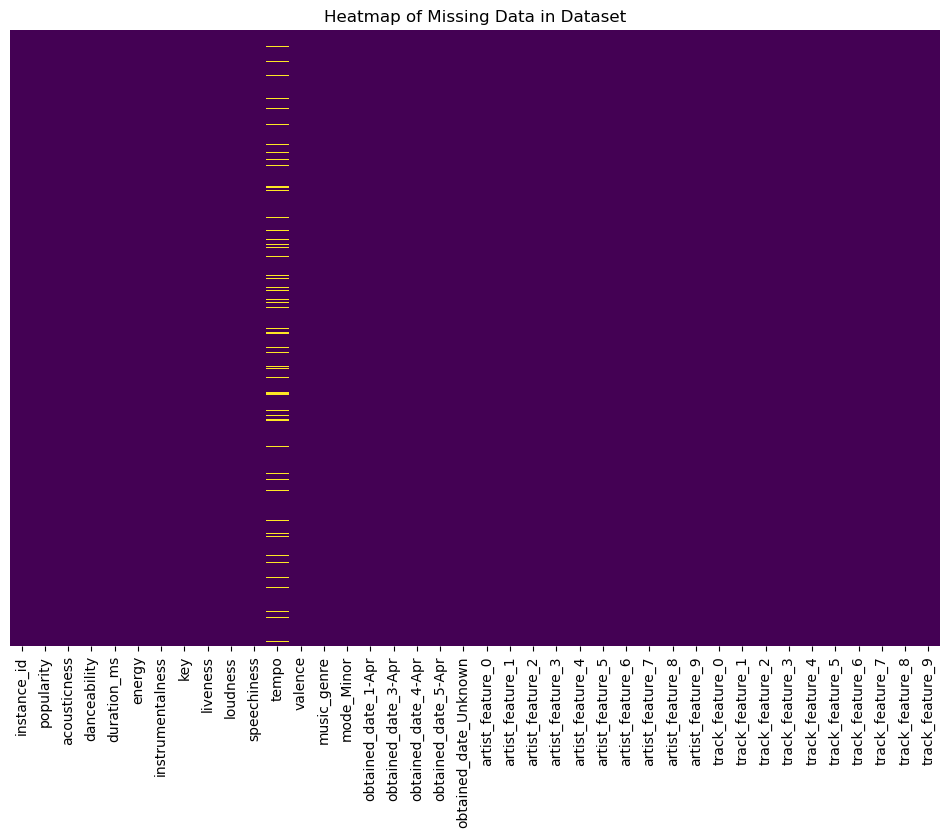

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a dataframe indicating where data is missing
missing_data = data.isnull()

# Plot the missingness heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(missing_data, cbar=False, yticklabels=False, cmap='viridis')
plt.title('Heatmap of Missing Data in Dataset')
plt.show()


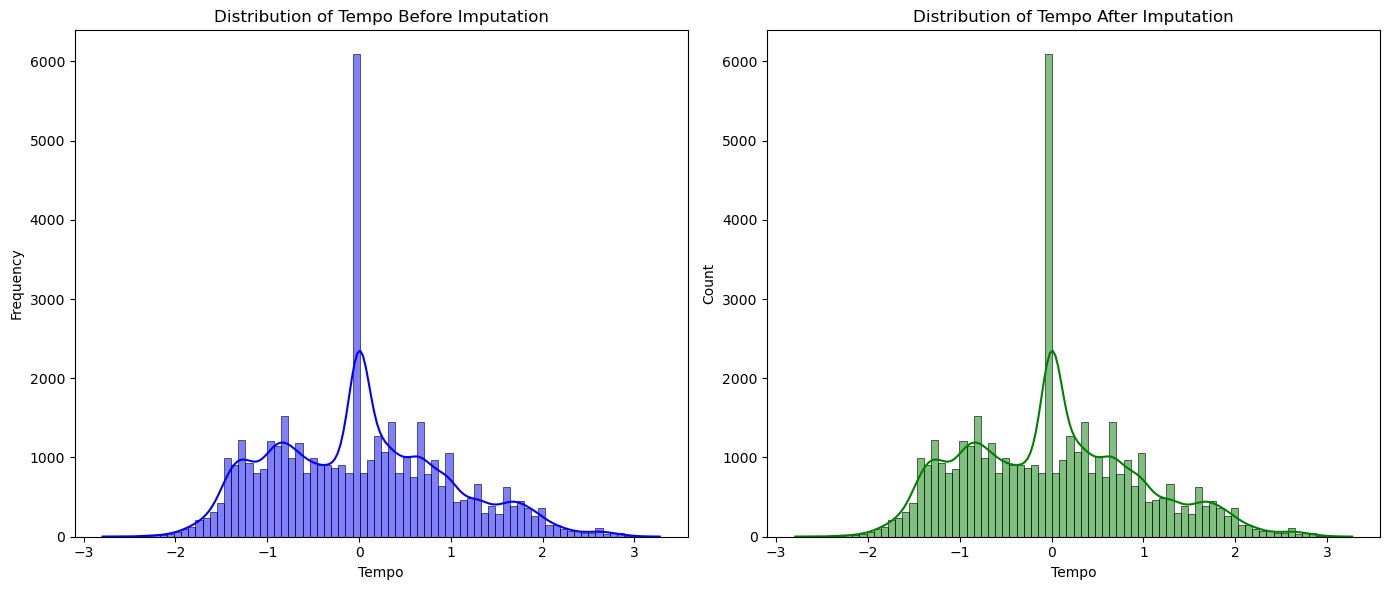

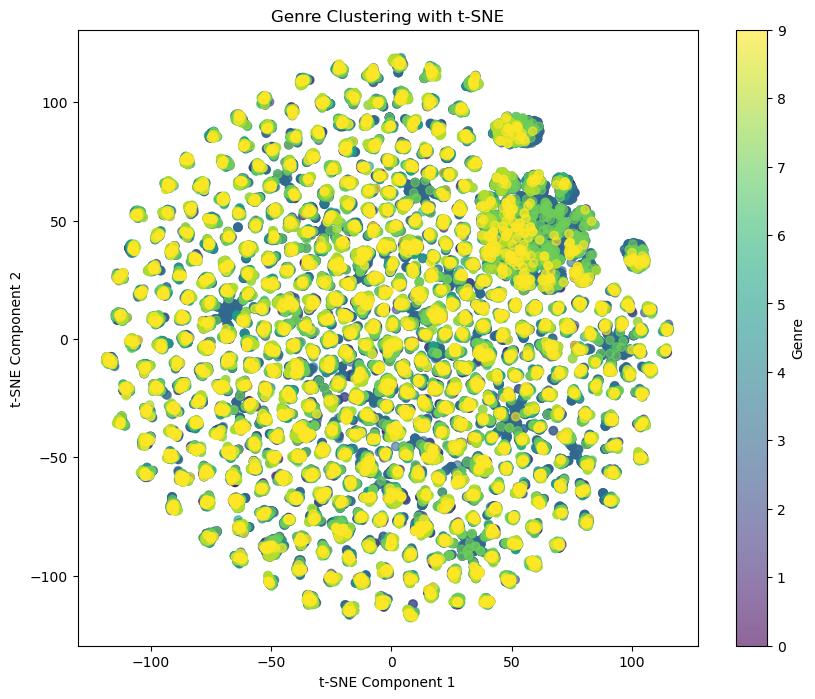

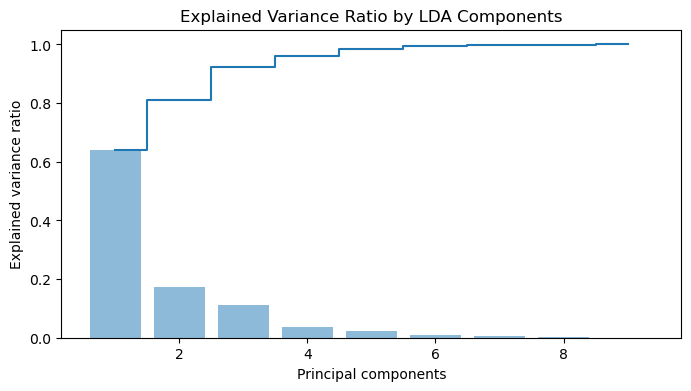

Reduced number of features to: 9


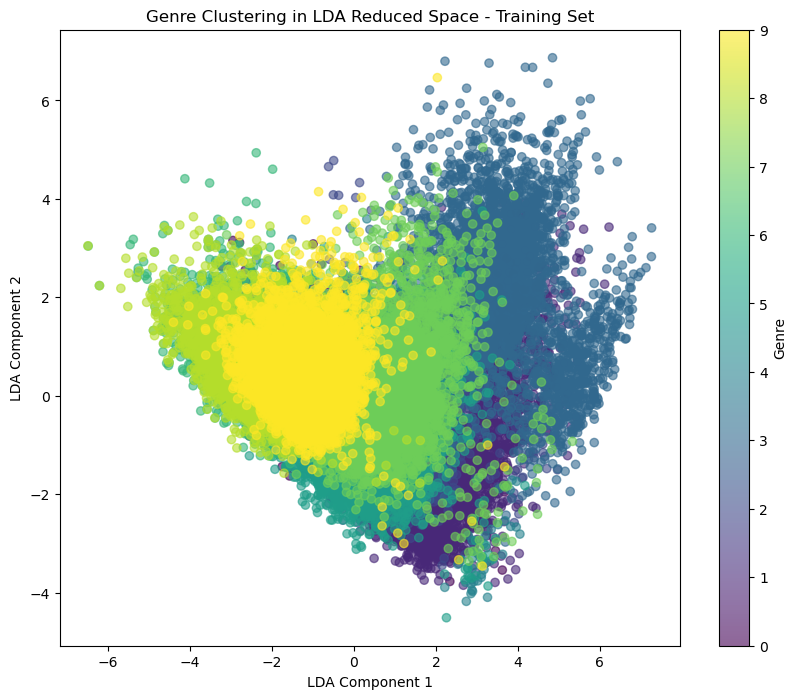

In [34]:
from sklearn.impute import KNNImputer
data = data.dropna()
train_frames = []
test_frames = []

for genre, group in data.groupby('music_genre'):
    # Determine the size of the test set dynamically, using a smaller size if the group is too small
    test_size = min(len(group), 500)  # Ensure test size does not exceed the group size
    if len(group) > test_size:
        train_grp, test_grp = train_test_split(group, test_size=test_size, random_state=42)
        train_frames.append(train_grp)
        test_frames.append(test_grp)
    else:
        print(f"Not enough data to split for genre: {genre} with only {len(group)} samples.")

train_data = pd.concat(train_frames)
test_data = pd.concat(test_frames)


X_train = train_data.drop('music_genre', axis=1)
y_train = train_data['music_genre']
X_test = test_data.drop('music_genre', axis=1)
y_test = test_data['music_genre']

original_tempo_train = X_train['tempo'].dropna().copy()
 #Initialize the KNN Imputer with 5 neighbors
imputer = KNNImputer(n_neighbors=5)

# Fit the imputer on the training data 'tempo' column
imputer.fit(X_train[['tempo']])

# Transform the 'tempo' column in both training and test sets
X_train['tempo'] = imputer.transform(X_train[['tempo']])
X_test['tempo'] = imputer.transform(X_test[['tempo']])

# Plotting both distributions: Before and After Imputation
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(original_tempo_train, kde=True, color='blue')
plt.title('Distribution of Tempo Before Imputation')
plt.xlabel('Tempo')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(X_train['tempo'], kde=True, color='green')
plt.title('Distribution of Tempo After Imputation')
plt.xlabel('Tempo')

plt.tight_layout()
plt.show()




# Scaling features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Applying t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=set_seed(15806679))
X_tsne = tsne.fit_transform(X_train)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Genre')
plt.title('Genre Clustering with t-SNE')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()
















import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans




lda = LDA(n_components=9)  
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

# The explained variance ratio can be calculated from the eigenvalues
explained_variance_ratio = lda.explained_variance_ratio_

# Visualizing the explained variance ratio
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.5, align='center')
plt.step(range(1, len(explained_variance_ratio) + 1), np.cumsum(explained_variance_ratio), where='mid')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.title('Explained Variance Ratio by LDA Components')
plt.show()
print("Reduced number of features to:", X_train_lda.shape[1])

import matplotlib.pyplot as plt

# Assuming you have already fitted LDA and transformed your data as X_train_lda and y_train are ready
plt.figure(figsize=(10, 8))
# Ensure that you use the same dataset for both x and y coordinates
scatter = plt.scatter(X_train_lda[:, 0], X_train_lda[:, 1], c=y_train, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Genre')
plt.xlabel('LDA Component 1')  # First LDA component
plt.ylabel('LDA Component 2')  # Second LDA component
plt.title('Genre Clustering in LDA Reduced Space - Training Set')
plt.show()


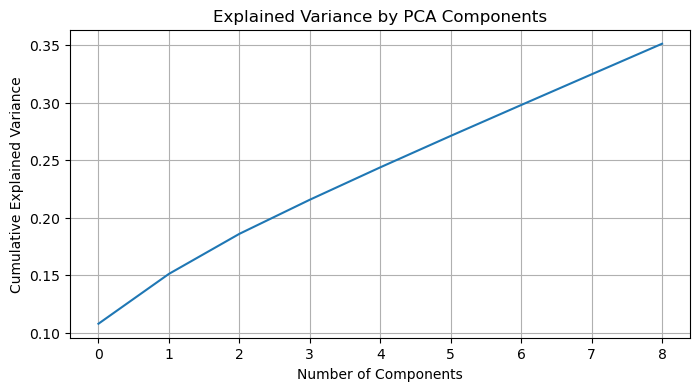

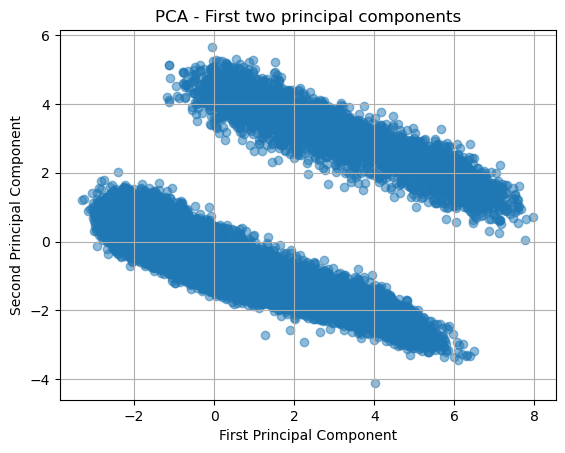

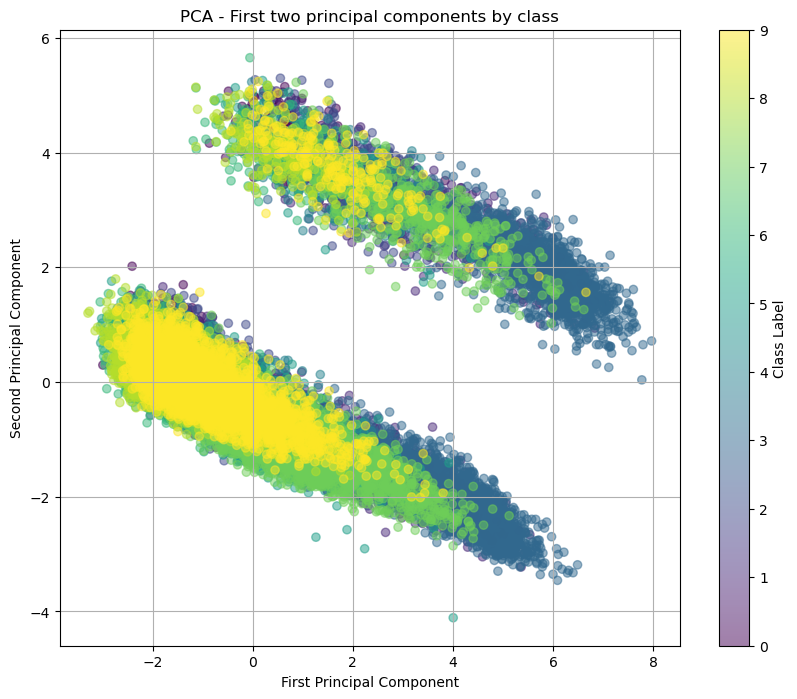

In [35]:
# Applying PCA
pca = PCA(n_components=9)  # Retains 95% of variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Scaling features


plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], alpha=0.5)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA - First two principal components')
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', alpha=0.5)
plt.colorbar(scatter, label='Class Label')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA - First two principal components by class')
plt.grid(True)
plt.show()



In [36]:
#4
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Define a range of potential clusters to test
range_n_clusters = list(range(2, 11))  # typically 2 to 10 clusters are sufficient for most practical purposes
silhouette_avg_scores = []

# Calculate silhouette scores for different values of k
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, random_state=set_seed(15806679))
    cluster_labels = kmeans.fit_predict(X_train_lda)
    silhouette_avg = silhouette_score(X_train_lda, cluster_labels)
    silhouette_avg_scores.append(silhouette_avg)
    print("For n_clusters =", num_clusters,
          "The average silhouette_score is :", silhouette_avg)

# Plot silhouette scores to visualize the best k
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_avg_scores, marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

For n_clusters = 2 The average silhouette_score is : 0.17525891208026884
For n_clusters = 3 The average silhouette_score is : 0.15399007364694242
For n_clusters = 4 The average silhouette_score is : 0.14356136539460737
For n_clusters = 5 The average silhouette_score is : 0.13593960367760746
For n_clusters = 6 The average silhouette_score is : 0.12144614996995391


KeyboardInterrupt: 

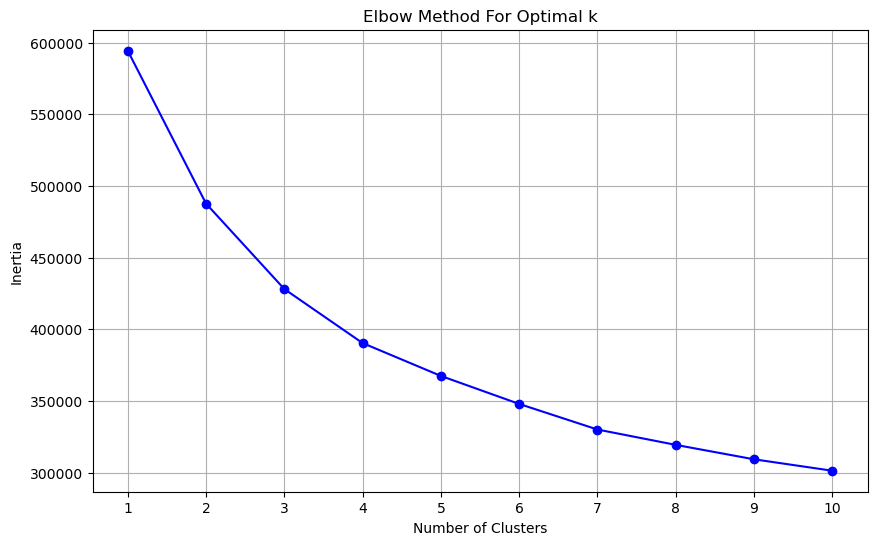

In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'X_mds' is your dataset after applying MDS as mentioned earlier
range_of_clusters = range(1, 11)  # Testing from 1 to 10 clusters
inertias = []

for k in range_of_clusters:
    kmeans = KMeans(n_clusters=k, random_state=set_seed(15806679))
    kmeans.fit(X_train_lda)
    inertias.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range_of_clusters, inertias, 'bo-')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range_of_clusters)  # Ensuring all cluster counts are marked
plt.grid(True)
plt.show()

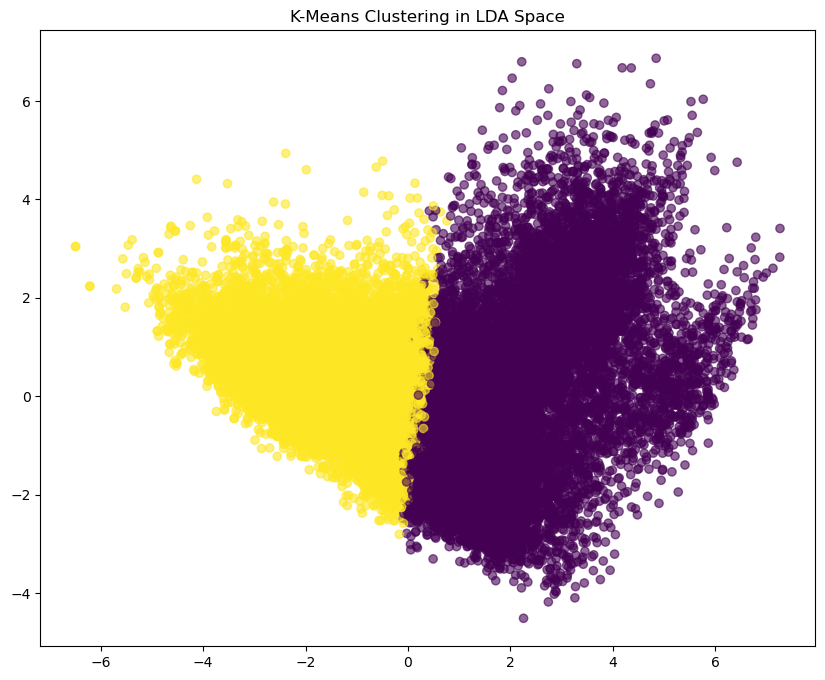

In [31]:


# Clustering
kmeans = KMeans(n_clusters=2, random_state=set_seed(15806679))  # Adjust the number of clusters based on your data
clusters = kmeans.fit_predict(X_train_lda)

plt.figure(figsize=(10, 8))
plt.scatter(X_train_lda[:, 0], X_train_lda[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.title('K-Means Clustering in LDA Space')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt




ada_model = AdaBoostClassifier(n_estimators=100, random_state=set_seed(15806679))
ada_model.fit(X_train_lda, y_train)
y_test_pred_ada = ada_model.predict(X_test_lda)

# rf_model = RandomForestClassifier(n_estimators=500, random_state=set_seed(15806679), class_weight='balanced')
# rf_model.fit(X_train_lda, y_train)
# y_test_pred_rf = rf_model.predict(X_test_lda)




from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Set a fixed random seed for reproducibility
random_state_value = 15806679

# Initialize and train the RandomForestClassifier with additional parameters
rf_model = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=10,
    random_state=random_state_value,
    class_weight='balanced'
)
rf_model.fit(X_train_lda, y_train)

# Make predictions on the test dataset
y_test_pred_rf = rf_model.predict(X_test_lda)

# Print the accuracy to evaluate the model
print("Accuracy:", accuracy_score(y_test, y_test_pred_rf))



logreg_model = LogisticRegression(random_state=set_seed(15806679), max_iter=1000)
logreg_model.fit(X_train_lda, y_train)
y_test_pred_logreg = logreg_model.predict(X_test_lda)

# # Evaluation
# print("AdaBoost Test Accuracy:", accuracy_score(y_test, y_test_pred_ada))
# print("Random Forest Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))
# print("Logistic Regression Test Accuracy:", accuracy_score(y_test, y_test_pred_logreg))


print("AdaBoost Test Accuracy:", accuracy_score(y_test, y_test_pred_ada))
print("Classification Report for AdaBoost on Test Set:")
print(classification_report(y_test, y_test_pred_ada))

# Evaluate Random Forest
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("Classification Report for Random Forest on Test Set:")
print(classification_report(y_test, y_test_pred_rf))

# Evaluate Logistic Regression
print("Logistic Regression Test Accuracy:", accuracy_score(y_test, y_test_pred_logreg))
print("Classification Report for Logistic Regression on Test Set:")
print(classification_report(y_test, y_test_pred_logreg))

/opt/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy: 0.5488
AdaBoost Test Accuracy: 0.4454
Classification Report for AdaBoost on Test Set:
              precision    recall  f1-score   support

           0       0.37      0.15      0.21       500
           1       0.42      0.78      0.55       500
           2       0.47      0.20      0.28       500
           3       0.63      0.64      0.63       500
           4       0.45      0.45      0.45       500
           5       0.54      0.33      0.41       500
           6       0.40      0.36      0.38       500
           7       0.44      0.43      0.44       500
           8       0.34      0.36      0.35       500
           9       0.44      0.74      0.55       500

    accuracy                           0.45      5000
   macro avg       0.45      0.45      0.43      5000
weighted avg       0.45      0.45      0.43      5000

Random Forest Test Accuracy: 0.5488
Classification Report for Random Forest on Test Set:
              precision    recall  f1-score   support

 

In [74]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Define the model
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Set up the parameter grid to sample from during fitting
param_distributions = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create the RandomizedSearchCV object
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_distributions, 
                                   n_iter=100, scoring='accuracy', cv=3, verbose=2, 
                                   random_state=42, n_jobs=-1)

# Fit the random search model
random_search.fit(X_train_lda, y_train)

# Get the best estimator
best_rf_model = random_search.best_estimator_

# Predict using the best model
y_test_pred_rf = best_rf_model.predict(X_test_lda)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_test_pred_rf))
print("Best Parameters:", random_search.best_params_)
print("Classification Report:\n", classification_report(y_test, y_test_pred_rf))


Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END max_depth=40, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   9.6s
[CV] END max_depth=40, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   9.7s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END max_depth=20, max_features=auto, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.0s
[CV] END max_depth=40, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=  10.0s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time=  22.1s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimator

/opt/miniconda3/envs/torch/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time= 1.0min
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=500; total time=  41.3s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=500; total time=  41.8s
[CV] END max_depth=10, max_features=log2, min_samples_leaf=4, min_samples_split=2, n_estimators=500; total time=  41.7s
[CV] END max_depth=20, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=400; total time=  48.7s
[CV] END max_depth=30, max_features=log2, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=  26.0s
[CV] END max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   0.0s
[CV] END max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time=   0.0s
[CV] END max_depth=10, max_features=auto

/opt/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:547: FitFailedWarning: 
90 fits failed out of a total of 300.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
48 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/base.py", line 1467, in wrapper
    estimator._validate_params()
  File "/opt/miniconda3/envs/torch/lib/python3.11/site-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints

Accuracy: 0.5418
Best Parameters: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
Classification Report:
               precision    recall  f1-score   support

           0       0.39      0.33      0.36       500
           1       0.75      0.70      0.72       500
           2       0.55      0.49      0.52       500
           3       0.84      0.82      0.83       500
           4       0.49      0.48      0.49       500
           5       0.61      0.59      0.60       500
           6       0.42      0.53      0.47       500
           7       0.50      0.47      0.48       500
           8       0.43      0.31      0.36       500
           9       0.47      0.70      0.56       500

    accuracy                           0.54      5000
   macro avg       0.55      0.54      0.54      5000
weighted avg       0.55      0.54      0.54      5000



AttributeError: module 'xgboost' has no attribute '__version__'

AttributeError: module 'xgboost' has no attribute 'DMatrix'

In [ ]:
print("Unique classes in y_train:", np.unique(y_train))
print("Unique classes in y_test:", np.unique(y_test))


Unique classes in y_train: [0 1 2 3 4 5 6 7 8 9]
Unique classes in y_test: [0 1 2 3 4 5 6 7 8 9]


X_train_torch shape: torch.Size([40020, 9])
y_train_torch shape: torch.Size([40020])
X_test_torch shape: torch.Size([5000, 9])
y_test_torch shape: torch.Size([5000])
9 10
Epoch 1/300, Train Loss: 1.4118, Test Loss: 1.2281, Train Acc: 0.4713, Test Acc: 0.5244, Average AUC: 0.9130
Epoch 2/300, Train Loss: 1.2961, Test Loss: 1.1958, Train Acc: 0.5143, Test Acc: 0.5394, Average AUC: 0.9155
Epoch 3/300, Train Loss: 1.2685, Test Loss: 1.1675, Train Acc: 0.5231, Test Acc: 0.5508, Average AUC: 0.9176
Epoch 4/300, Train Loss: 1.2503, Test Loss: 1.1602, Train Acc: 0.5266, Test Acc: 0.5468, Average AUC: 0.9188
Epoch 5/300, Train Loss: 1.2359, Test Loss: 1.1553, Train Acc: 0.5325, Test Acc: 0.5532, Average AUC: 0.9192
Epoch 6/300, Train Loss: 1.2322, Test Loss: 1.1513, Train Acc: 0.5336, Test Acc: 0.5496, Average AUC: 0.9199
Epoch 7/300, Train Loss: 1.2222, Test Loss: 1.1441, Train Acc: 0.5346, Test Acc: 0.5534, Average AUC: 0.9217
Epoch 8/300, Train Loss: 1.2141, Test Loss: 1.1443, Train Acc: 0.5

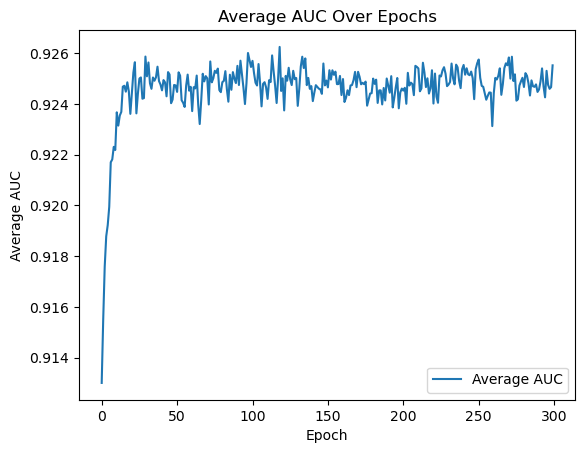

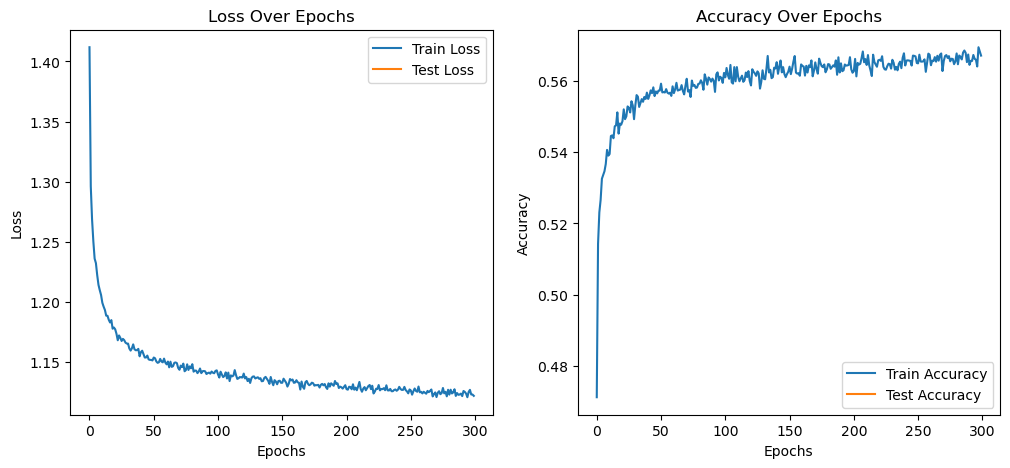

In [114]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Assuming X_train_lda, y_train, X_test_lda, y_test are already defined and are numpy arrays

# Convert data to PyTorch tensors
X_train_torch = torch.tensor(X_train_lda.astype(np.float32))
y_train_torch = torch.tensor(y_train.to_numpy().astype(np.int64))
X_test_torch = torch.tensor(X_test_lda.astype(np.float32))
y_test_torch = torch.tensor(y_test.to_numpy().astype(np.int64))


# Create Tensor datasets
train_dataset = TensorDataset(X_train_torch, y_train_torch)
test_dataset = TensorDataset(X_test_torch, y_test_torch)

# Create Data Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print("X_train_torch shape:", X_train_torch.shape)
print("y_train_torch shape:", y_train_torch.shape)
print("X_test_torch shape:", X_test_torch.shape)
print("y_test_torch shape:", y_test_torch.shape)

# Define the neural network model
class MLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 256),  # First layer with more neurons
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),  #
            nn.ReLU(),
            nn.Dropout(0.3),      # Adjusted dropout rate
            nn.Linear(128, 64),   # Additional layer
            nn.ReLU(),
            nn.Dropout(0.2),      # Adjusted dropout rate
            nn.Linear(64, 32),    # Additional layer
            nn.ReLU(),
            nn.Linear(32, num_classes) 
        )
        
    def forward(self, x):
        return self.layers(x)



# Initialize the model with the correct number of features
input_size = X_train_lda.shape[1]
num_classes = len(np.unique(y_train))  # Adjust based on actual data
print(input_size,num_classes)
model = MLP(input_size, num_classes)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=300):
    train_losses, test_losses = [], []
    train_accuracies, test_accuracies = [], []
    epoch_auc = []  # List to store average AUC for each epoch

    num_classes = model.layers[-1].out_features  # Assuming the last layer's out_features attribute holds the number of classes

    for epoch in range(num_epochs):
        model.train()  # Training mode
        train_loss = 0
        correct_train = 0
        total_train = 0

        for data, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * data.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += targets.size(0)
            correct_train += (predicted == targets).sum().item()

        train_losses.append(train_loss / total_train)
        train_accuracies.append(correct_train / total_train)



        model.eval()  # Evaluation mode
        test_loss = 0
        correct_test = 0
        total_test = 0
        all_probabilities = []
        all_targets = []
        
        with torch.no_grad():
            for data, targets in test_loader:
                outputs = model(data)
                loss = criterion(outputs, targets)
                test_loss += loss.item() * data.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_test += targets.size(0)
                correct_test += (predicted == targets).sum().item()

                probabilities = torch.softmax(outputs, dim=1)
                all_probabilities.append(probabilities)
                all_targets.append(targets)

        # Reshape all_probabilities and all_targets to single numpy arrays
        all_probabilities = torch.cat(all_probabilities).cpu().numpy()
        all_targets = torch.cat(all_targets).cpu().numpy()

        # Binarize the labels for multi-class roc_auc_score
        all_targets = label_binarize(all_targets, classes=[i for i in range(num_classes)])
        
        # Calculate the AUC for each class and average them
        auc_scores = [roc_auc_score(all_targets[:, i], all_probabilities[:, i]) for i in range(num_classes)]
        average_auc = np.mean(auc_scores)
        epoch_auc.append(average_auc)
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss / total_train:.4f}, '
              f'Test Loss: {test_loss / total_test:.4f}, Train Acc: {correct_train / total_train:.4f}, '
              f'Test Acc: {correct_test / total_test:.4f}, Average AUC: {average_auc:.4f}')

    # Plot average AUC over epochs
    plt.figure()
    plt.plot(epoch_auc, label='Average AUC')
    plt.xlabel('Epoch')
    plt.ylabel('Average AUC')
    plt.title('Average AUC Over Epochs')
    plt.legend()
    plt.show()

    return train_losses, test_losses, train_accuracies, test_accuracies, epoch_auc










# Train the model and collect metrics

# Call the function and capture all return values
train_losses, test_losses, train_accuracies, test_accuracies, epoch_auc = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=300)

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

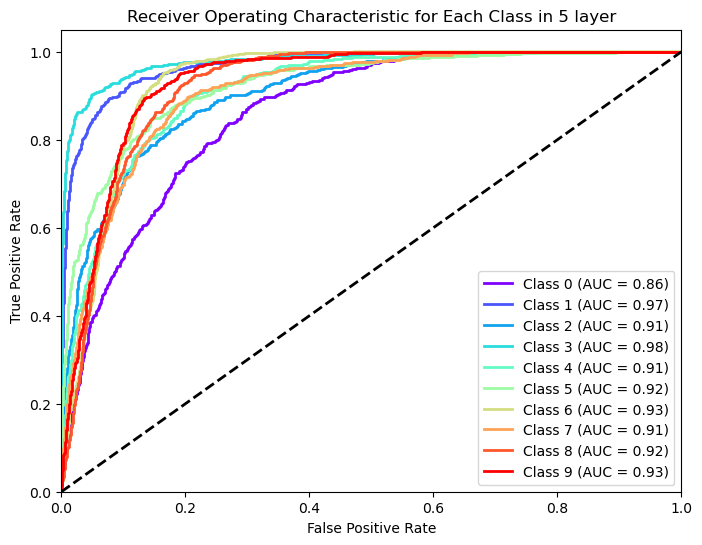

In [115]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader

def evaluate_mlp_roc_auc(model, loader, classes, device='cpu'):
    """
    Evaluates a PyTorch MLP model by plotting ROC curves and calculating AUC for a multi-class classification problem.

    Parameters:
        model (torch.nn.Module): The trained neural network model.
        loader (DataLoader): DataLoader for the dataset to evaluate.
        classes (list): List of unique class labels.
        device (str): The device ('cpu' or 'cuda') the model should use for inference.
    """
    model.eval()  # Set the model to evaluation mode
    y_true = []
    y_scores = []

     # Gather all labels and predictions
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probabilities = torch.softmax(outputs, dim=1)  # Convert logits to probabilities
            y_scores.extend(probabilities.cpu().numpy())  # Store probabilities
            y_true.extend(labels.cpu().numpy())  # Store true labels

    # Binarize the labels for ROC curve
    y_true_binarized = label_binarize(y_true, classes=classes)
    n_classes = len(classes)

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], [p[i] for p in y_scores])
        roc_auc[i] = auc(fpr[i], tpr[i])



 # Plot all ROC curves
    plt.figure(figsize=(8, 6))
    colors = iter(plt.cm.rainbow(np.linspace(0, 1, n_classes)))
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='Class {0} (AUC = {1:0.2f})'.format(classes[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic for Each Class in 5 layer')
    plt.legend(loc="lower right")
    plt.show()



 #Call the evaluation function
classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # Classes in your classification problem
roc_auc_scores = evaluate_mlp_roc_auc(model, test_loader, classes, device='cpu')



In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader

In [105]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
# 8 linear layers 
class MLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 128),  # Extra middle layer
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 32),   # Extra middle layer
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.layers(x)

# Initialize the model with the correct number of features
input_size = X_train_lda.shape[1]
num_classes = len(np.unique(y_train))  # Adjust based on actual data
print(input_size,num_classes)
model = MLP(input_size, num_classes)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=300):
    train_losses, test_losses = [], []
    train_accuracies, test_accuracies = [], []
    epoch_auc = []  # List to store average AUC for each epoch

    num_classes = model.layers[-1].out_features  # Assuming the last layer's out_features attribute holds the number of classes

    for epoch in range(num_epochs):
        model.train()  # Training mode
        train_loss = 0
        correct_train = 0
        total_train = 0

        for data, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * data.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += targets.size(0)
            correct_train += (predicted == targets).sum().item()

        train_losses.append(train_loss / total_train)
        train_accuracies.append(correct_train / total_train)

        model.eval()  # Evaluation mode
        test_loss = 0
        correct_test = 0
        total_test = 0
        all_probabilities = []
        all_targets = []
        
        with torch.no_grad():
            for data, targets in test_loader:
                outputs = model(data)
                loss = criterion(outputs, targets)
                test_loss += loss.item() * data.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_test += targets.size(0)
                correct_test += (predicted == targets).sum().item()

                probabilities = torch.softmax(outputs, dim=1)
                all_probabilities.append(probabilities)
                all_targets.append(targets)

        # Reshape all_probabilities and all_targets to single numpy arrays
        all_probabilities = torch.cat(all_probabilities).cpu().numpy()
        all_targets = torch.cat(all_targets).cpu().numpy()

        # Binarize the labels for multi-class roc_auc_score
        all_targets = label_binarize(all_targets, classes=[i for i in range(num_classes)])
        
        # Calculate the AUC for each class and average them
        auc_scores = [roc_auc_score(all_targets[:, i], all_probabilities[:, i]) for i in range(num_classes)]
        average_auc = np.mean(auc_scores)
        epoch_auc.append(average_auc)

        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss / total_train:.4f}, '
              f'Test Loss: {test_loss / total_test:.4f}, Train Acc: {correct_train / total_train:.4f}, '
              f'Test Acc: {correct_test / total_test:.4f}, Average AUC: {average_auc:.4f}')

    # Plot average AUC over epochs
    plt.figure()
    plt.plot(epoch_auc, label='Average AUC')
    plt.xlabel('Epoch')
    plt.ylabel('Average AUC')
    plt.title('Average AUC Over Epochs')
    plt.legend()
    plt.show()

    return train_losses, test_losses, train_accuracies, test_accuracies, epoch_auc



# Call the function and capture all return values
train_losses, test_losses, train_accuracies, test_accuracies, epoch_auc = train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=300)

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()









9 10
Epoch 1/300, Train Loss: 1.5665, Test Loss: 1.3306, Train Acc: 0.4046, Test Acc: 0.4934, Average AUC: 0.8926
Epoch 2/300, Train Loss: 1.3915, Test Loss: 1.2779, Train Acc: 0.4906, Test Acc: 0.5130, Average AUC: 0.8995
Epoch 3/300, Train Loss: 1.3561, Test Loss: 1.2431, Train Acc: 0.5074, Test Acc: 0.5318, Average AUC: 0.9045
Epoch 4/300, Train Loss: 1.3362, Test Loss: 1.2563, Train Acc: 0.5124, Test Acc: 0.5258, Average AUC: 0.9064
Epoch 5/300, Train Loss: 1.3147, Test Loss: 1.2187, Train Acc: 0.5175, Test Acc: 0.5386, Average AUC: 0.9106
Epoch 6/300, Train Loss: 1.3017, Test Loss: 1.2075, Train Acc: 0.5234, Test Acc: 0.5508, Average AUC: 0.9119
Epoch 7/300, Train Loss: 1.2965, Test Loss: 1.2224, Train Acc: 0.5223, Test Acc: 0.5468, Average AUC: 0.9105
Epoch 8/300, Train Loss: 1.2891, Test Loss: 1.1829, Train Acc: 0.5254, Test Acc: 0.5508, Average AUC: 0.9153
Epoch 9/300, Train Loss: 1.2755, Test Loss: 1.1843, Train Acc: 0.5285, Test Acc: 0.5502, Average AUC: 0.9152
Epoch 10/300, 

KeyboardInterrupt: 

In [112]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, auc
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader

def evaluate_mlp_roc_auc(model, loader, classes, device='cpu'):
    """
    Evaluates a PyTorch MLP model by plotting ROC curves and calculating AUC for a multi-class classification problem.

    Parameters:
        model (torch.nn.Module): The trained neural network model.
        loader (DataLoader): DataLoader for the dataset to evaluate.
        classes (list): List of unique class labels.
        device (str): The device ('cpu' or 'cuda') the model should use for inference.
    """
    model.eval()  # Set the model to evaluation mode
    y_true = []
    y_scores = []

    # Gather all labels and predictions
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probabilities = torch.softmax(outputs, dim=1)  # Convert logits to probabilities
            y_scores.extend(probabilities.cpu().numpy())  # Store probabilities
            y_true.extend(labels.cpu().numpy())  # Store true labels

    # Binarize the labels for ROC curve
    y_true_binarized = label_binarize(y_true, classes=classes)
    n_classes = len(classes)

    # Compute ROC curve and ROC area for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], [p[i] for p in y_scores])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(8, 6))
    colors = iter(plt.cm.rainbow(np.linspace(0, 1, n_classes)))
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='Class {0} (AUC = {1:0.2f})'.format(classes[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic for Each Class in 8 layer')
    plt.legend(loc="lower right")
    plt.show()

    return roc_auc


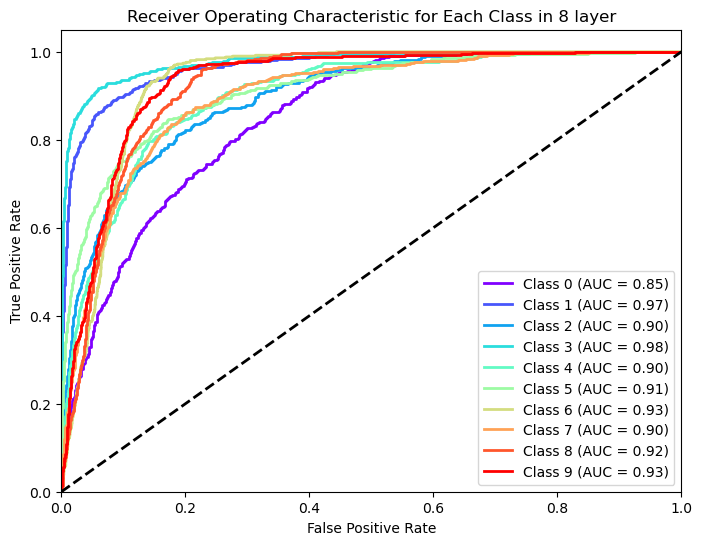

In [113]:
 #Call the evaluation function
classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # Classes in your classification problem
roc_auc_scores = evaluate_mlp_roc_auc(model, test_loader, classes, device='cpu')

AUC Scores for AdaBoost:
Class 0: AUC = 0.44
Class 1: AUC = 0.90
Class 2: AUC = 0.65
Class 3: AUC = 0.94
Class 4: AUC = 0.58
Class 5: AUC = 0.65
Class 6: AUC = 0.91
Class 7: AUC = 0.61
Class 8: AUC = 0.90
Class 9: AUC = 0.75


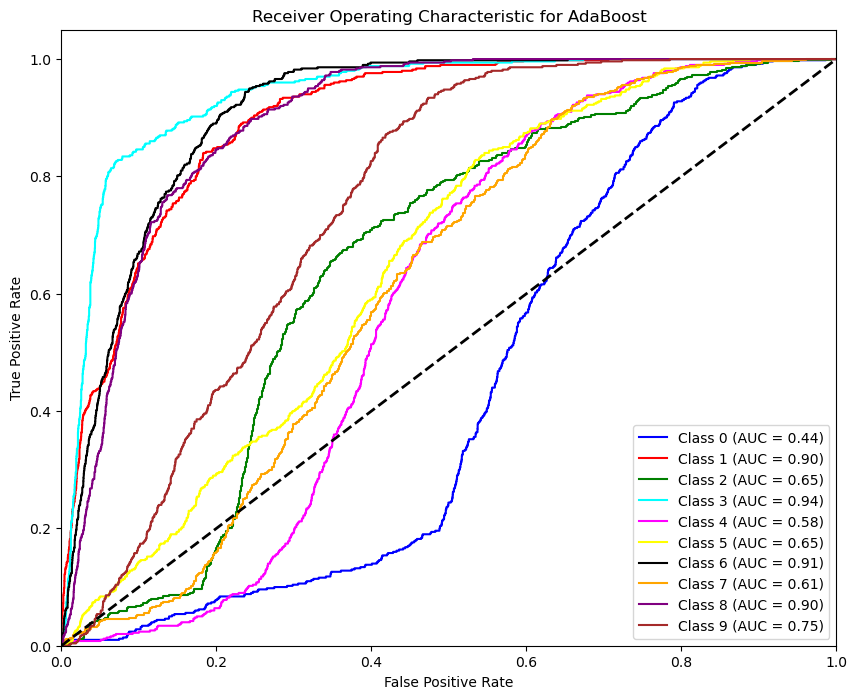

AUC Scores for RandomForest:
Class 0: AUC = 0.85
Class 1: AUC = 0.96
Class 2: AUC = 0.90
Class 3: AUC = 0.98
Class 4: AUC = 0.90
Class 5: AUC = 0.92
Class 6: AUC = 0.92
Class 7: AUC = 0.90
Class 8: AUC = 0.92
Class 9: AUC = 0.93


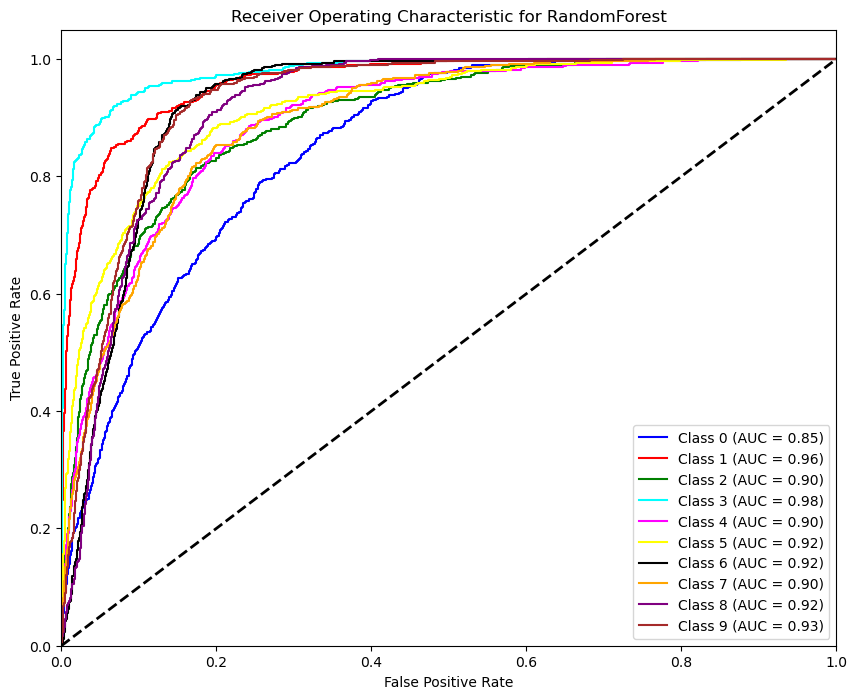

AUC Scores for Logistic Regression:
Class 0: AUC = 0.83
Class 1: AUC = 0.94
Class 2: AUC = 0.88
Class 3: AUC = 0.97
Class 4: AUC = 0.88
Class 5: AUC = 0.90
Class 6: AUC = 0.92
Class 7: AUC = 0.87
Class 8: AUC = 0.92
Class 9: AUC = 0.93


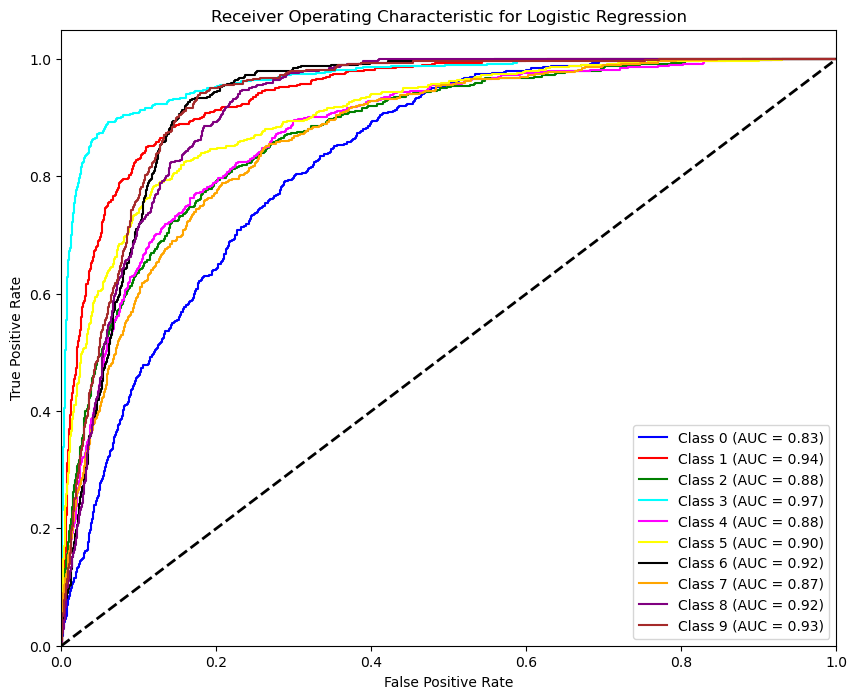

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

def plot_multiclass_roc(clf, X_test, y_test, classes, classifier_name):
    """
    Plot ROC curves and print AUC scores for the multiclass problem.
    
    Parameters:
        clf (classifier): The classifier to use (must have a predict_proba method).
        X_test (DataFrame or array): Test features.
        y_test (array): True labels for test set.
        classes (array): Array of unique class labels.
        classifier_name (str): Name of the classifier for plot labeling.
    """
    # Binarize the output labels for multi-class classification
    y_test_binarized = label_binarize(y_test, classes=classes)

    # Get the model probability predictions
    y_score = clf.predict_proba(X_test)

    # Setup ROC curve characteristics
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    print(f'AUC Scores for {classifier_name}:')
    for i, label in enumerate(classes):
        fpr[label], tpr[label], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
        roc_auc[label] = roc_auc_score(y_test_binarized[:, i], y_score[:, i])
        print(f"Class {label}: AUC = {roc_auc[label]:.2f}")

    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    colors = ['blue', 'red', 'green', 'cyan', 'magenta', 'yellow', 'black', 'orange', 'purple', 'brown']
    for i, color in zip(range(len(classes)), colors):
        plt.plot(fpr[classes[i]], tpr[classes[i]], color=color,
                 label='Class {0} (AUC = {1:0.2f})'.format(classes[i], roc_auc[classes[i]]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic for {}'.format(classifier_name))
    plt.legend(loc="lower right")
    plt.show()


# Example usage after training AdaBoost, RandomForest, and Logistic Regression
# Correct usage of plot_multiclass_roc with LDA-transformed data
plot_multiclass_roc(ada_model, X_test_lda, y_test, classes=np.unique(y_test), classifier_name='AdaBoost')
plot_multiclass_roc(rf_model, X_test_lda, y_test, classes=np.unique(y_test), classifier_name='RandomForest')
plot_multiclass_roc(logreg_model, X_test_lda, y_test, classes=np.unique(y_test), classifier_name='Logistic Regression')


AttributeError: module 'xgboost' has no attribute 'DMatrix'